# Ana

## Carga de Datos

In [21]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 1. Carga del dataset
df = pd.read_csv('data/Teen_Mental_Health_Dataset.csv')
# 2. Visualizar las primeras 5 filas
print("--- Primeras filas del dataset ---")
display(df.head())

# 3. Inspección de tipos de datos y valores no nulos
print("\n--- Información general del DataFrame ---")
df.info()

--- Primeras filas del dataset ---


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0



--- Información general del DataFrame ---
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)

## Normalización y duplicados

In [5]:
# 1. Comprobar y eliminar duplicados
duplicados = df.duplicated().sum()
print(f"Filas duplicadas detectadas: {duplicados}")

if duplicados > 0:
    df.drop_duplicates(inplace=True)
    print("¡Duplicados eliminados!")

Filas duplicadas detectadas: 0


In [8]:
# Comprobar los valores únicos exactos de las columnas categóricas
print("Valores únicos en 'gender':")
print(df['gender'].unique())

print("\nValores únicos en 'platform_usage':")
print(df['platform_usage'].unique())

print("\nValores únicos en 'social_interaction_level':")
print(df['social_interaction_level'].unique())

Valores únicos en 'gender':
<StringArray>
['male', 'female']
Length: 2, dtype: str

Valores únicos en 'platform_usage':
<StringArray>
['Instagram', 'TikTok', 'Both']
Length: 3, dtype: str

Valores únicos en 'social_interaction_level':
<StringArray>
['low', 'high', 'medium']
Length: 3, dtype: str


In [9]:
df['academic_performance_10'] = df['academic_performance'] * 2.5

## Tratamiento de Outliers

In [10]:

# Separamos la variable objetivo si existe
X = df.drop(columns=['depression_label'], errors='ignore')

# Variables para el modelo
categorical_cols = ['gender', 'platform_usage', 'social_interaction_level']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

In [11]:
# MÉTODO 1: Detección Multivariante con Machine Learning (Isolation Forest)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ])

X_processed = preprocessor.fit_transform(X)

# Estimamos un 5% de outliers
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['iforest_outlier'] = iso_forest.fit_predict(X_processed)
# Convertimos a Booleano (True para outlier, False para normal)
df['iforest_outlier'] = df['iforest_outlier'] == -1

In [12]:
# MÉTODO 2: Detección Univariante Estadística (IQR - Rango Intercuartílico)
# Marcamos como outlier si está fuera de [Q1 - 1.5*IQR, Q3 + 1.5*IQR] en CUALQUIER columna numérica
iqr_outliers = pd.Series(False, index=df.index)

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Condición de outlier para esta columna
    col_outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
    iqr_outliers = iqr_outliers | col_outliers

df['iqr_outlier'] = iqr_outliers

In [13]:
# 3. Reporte de Resultados en Consola
print(f"\n --- REPORTE DE OUTLIERS ---")
print(f"Outliers por Isolation Forest (Multivariante): {df['iforest_outlier'].sum()}")
print(f"Outliers por IQR (Univariante por columna): {df['iqr_outlier'].sum()}")


 --- REPORTE DE OUTLIERS ---
Outliers por Isolation Forest (Multivariante): 60
Outliers por IQR (Univariante por columna): 0


/var/folders/s2/hhmcyygd6hvcg30hhhb4294h0000gn/T/ipykernel_47221/1493726229.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='platform_usage', y='daily_social_media_hours', data=df, palette='Blues')


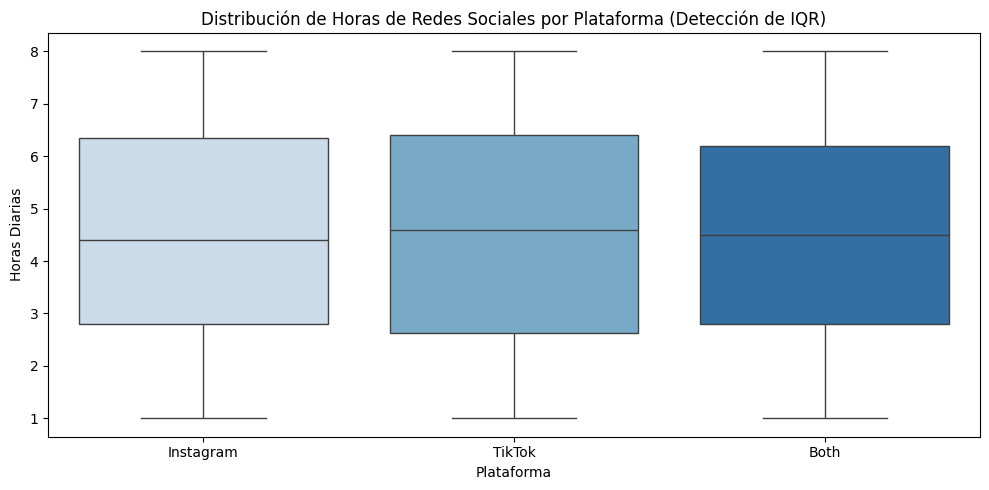

----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 62808)
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.3/Frameworks/Python.framework/Versions/3.13/lib/python3.13/socketserver.py", line 318, in _handle_request_noblock
    self.process_request(request, client_address)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Cellar/python@3.13/3.13.3/Frameworks/Python.framework/Versions/3.13/lib/python3.13/socketserver.py", line 349, in process_request
    self.finish_request(request, client_address)
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Cellar/python@3.13/3.13.3/Frameworks/Python.framework/Versions/3.13/lib/python3.13/socketserver.py", line 362, in finish_request
    self.RequestHandlerClass(request, client_address, self)
    ~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Cellar/python@3.13/3.13.3/Frameworks/Python.fra

In [14]:
# 4. Visualización de Datos

# Gráfico 1: Seaborn (Boxplot estático para ver la distribución de horas de redes sociales)
plt.figure(figsize=(10, 5))
sns.boxplot(x='platform_usage', y='daily_social_media_hours', data=df, palette='Blues')
plt.title('Distribución de Horas de Redes Sociales por Plataforma (Detección de IQR)')
plt.xlabel('Plataforma')
plt.ylabel('Horas Diarias')
plt.tight_layout()
plt.show()

# Gráfico 2: Plotly (Dispersión Interactiva en 3D usando NumPy para el tamaño)
# Analizamos Horas de Uso vs Estrés vs Rendimiento Académico
fig = px.scatter_3d(
    df, 
    x='daily_social_media_hours', 
    y='stress_level', 
    z='academic_performance',
    color='iforest_outlier', # Colorea según si es outlier por Isolation Forest
    color_discrete_map={False: "#12649e", True: "#f80b0b"}, # Azul formal vs Rojo outlier
    labels={'iforest_outlier': '¿Es Outlier?'},
    title="Análisis de Outliers Multivariante (Isolation Forest)",
    hover_data=['age', 'gender', 'addiction_level'] # Datos al pasar el ratón
)

fig.update_layout(scene=dict(
    xaxis_title='Horas Redes Sociales',
    yaxis_title='Nivel de Estrés',
    zaxis_title='Rendimiento Académico'
))

# 🌟 ALTERNATIVA A NBFORMAT: Forzar renderizado directo en el navegador web
import plotly.io as pio
pio.renderers.default = "browser"

fig.show()

# 5. Guardar resultados
df.to_csv('data\\outliers\\data_con_outliers.csv', index=False)

## Distribución de la variable objetivo

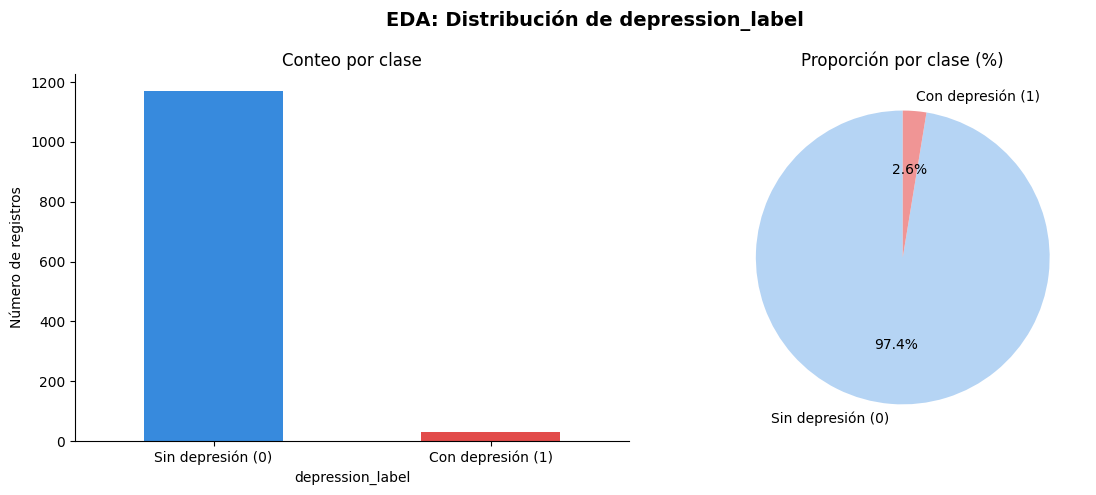

In [27]:
# 1. Carga de datos
df = pd.read_csv('data/Teen_Mental_Health_Dataset.csv')

# 2. Preparación de los datos con Pandas
conteo = df['depression_label'].value_counts()
etiquetas = ['Sin depresión (0)', 'Con depresión (1)']
colores = ['#378ADD', '#E24B4A']

# 3. Configuración del lienzo (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('EDA: Distribución de depression_label', fontsize=14, fontweight='bold')

# --- Gráfico 1: Barras usando PANDAS .plot() ---
conteo.plot(
    kind='bar', 
    ax=axes[0], 
    color=colores, 
    rot=0 # Evita que las etiquetas del eje X salgan rotadas
)
axes[0].set_title('Conteo por clase')
axes[0].set_xticklabels(etiquetas)
axes[0].set_ylabel('Número de registros')
axes[0].spines[['top', 'right']].set_visible(False)

# --- Gráfico 2: Pastel usando PANDAS .plot() ---
conteo.plot(
    kind='pie', 
    ax=axes[1], 
    labels=etiquetas, 
    colors=['#B5D4F4', '#F09595'], 
    autopct='%1.1f%%', 
    startangle=90
)
axes[1].set_title('Proporción por clase (%)')
axes[1].set_ylabel('') # Remueve el texto 'depression_label' que Pandas pone por defecto a un lado

# 4. Mostrar en pantalla (sin guardar archivos)
plt.tight_layout()
plt.show()

Si en este momento entrenamos el modelo con estos datos no podremos saber el nivel de relación entre variables pues la mayoria de los casos los estudiantes están marcados como que no tienen depresion, es por eso que cambiaremos a una variable contnua.

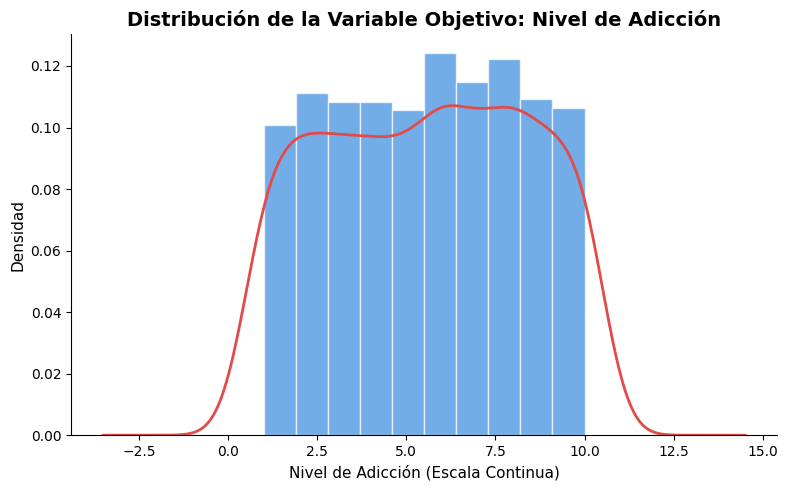

In [28]:
# 2. Configurar el lienzo para un solo gráfico limpio
fig, ax = plt.subplots(figsize=(8, 5))

# 3. Graficar Histograma + KDE usando Pandas
# 'density=True' es vital para que la curva del KDE se pueda dibujar a la misma escala
df['addiction_level'].plot(kind='hist', bins=10, density=True, ax=ax, 
                           color='#378ADD', edgecolor='white', alpha=0.7)

df['addiction_level'].plot(kind='kde', ax=ax, color='#E24B4A', linewidth=2)

# 4. Estética y etiquetas (¡Siempre pensando en que el negocio lo entienda!)
ax.set_title('Distribución de la Variable Objetivo: Nivel de Adicción', fontsize=14, fontweight='bold')
ax.set_xlabel('Nivel de Adicción (Escala Continua)', fontsize=11)
ax.set_ylabel('Densidad', fontsize=11)
ax.spines[['top', 'right']].set_visible(False) # Limpiamos líneas innecesarias

# 5. Mostrar en pantalla directamente
plt.tight_layout()
plt.show()

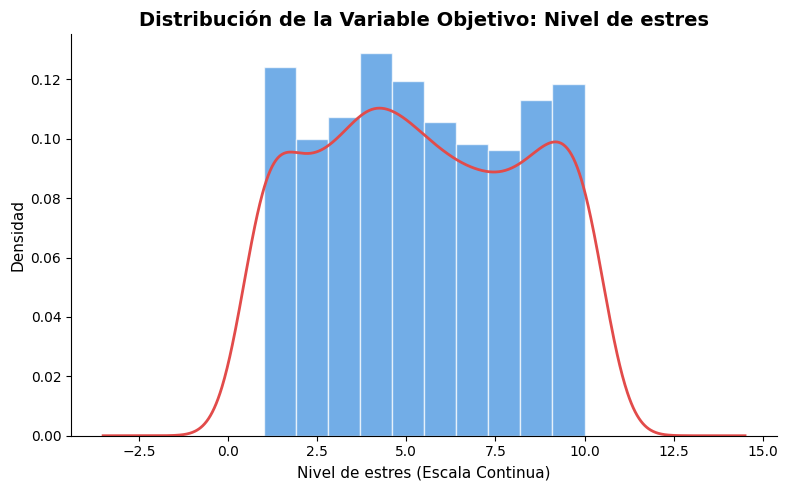

In [29]:
# 2. Configurar el lienzo para un solo gráfico limpio
fig, ax = plt.subplots(figsize=(8, 5))

# 3. Graficar Histograma + KDE usando Pandas
# 'density=True' es vital para que la curva del KDE se pueda dibujar a la misma escala
df['stress_level'].plot(kind='hist', bins=10, density=True, ax=ax, 
                           color='#378ADD', edgecolor='white', alpha=0.7)

df['stress_level'].plot(kind='kde', ax=ax, color='#E24B4A', linewidth=2)

# 4. Estética y etiquetas (¡Siempre pensando en que el negocio lo entienda!)
ax.set_title('Distribución de la Variable Objetivo: Nivel de estres', fontsize=14, fontweight='bold')
ax.set_xlabel('Nivel de estres (Escala Continua)', fontsize=11)
ax.set_ylabel('Densidad', fontsize=11)
ax.spines[['top', 'right']].set_visible(False) # Limpiamos líneas innecesarias

# 5. Mostrar en pantalla directamente
plt.tight_layout()
plt.show()

### Concluiones

- **Desbalance de Clases Extremo:** La variable objetivo presenta una asimetría crítica. La clase mayoritaria (Jóvenes sin síntomas de depresión - 0) representa el 96% de los datos, mientras que la clase de interés o minoritaria (Jóvenes con síntomas de depresión - 1) equivale únicamente al 4%.
Escasez de Señal: Al tener una proporción tan pequeña de la clase 1, el dataset cuenta con muy pocos ejemplos reales para que un algoritmo aprenda a identificar los patrones o comportamientos específicos de un adolescente en riesgo

- **Inutilidad del Accuracy (Precisión Global):** No se puede utilizar el Accuracy como métrica para evaluar los modelos predictivos. Un modelo "perezoso" que simplemente clasifique a todos los jóvenes como 0 (sin depresión) obtendría un 97.4% de precisión matemática, pero sería un fracaso analítico absoluto al no detectar a ningún individuo enfermo.

- **Sesgo del Algoritmo hacia la Clase Mayoritaria:** Cualquier modelo de Machine Learning tradicional entrenado con estos datos tal cual están tenderá a ignorar la clase 1. El algoritmo buscará optimizar su tasa de acierto general enfocándose en los registros de la clase 0, que son los que abundan.

## Análisis Univariado

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


In [30]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,academic_performance_10
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833,7.475958
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704,1.441894
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000,5.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000,6.250000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000,7.475000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000,8.700000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000,10.000000


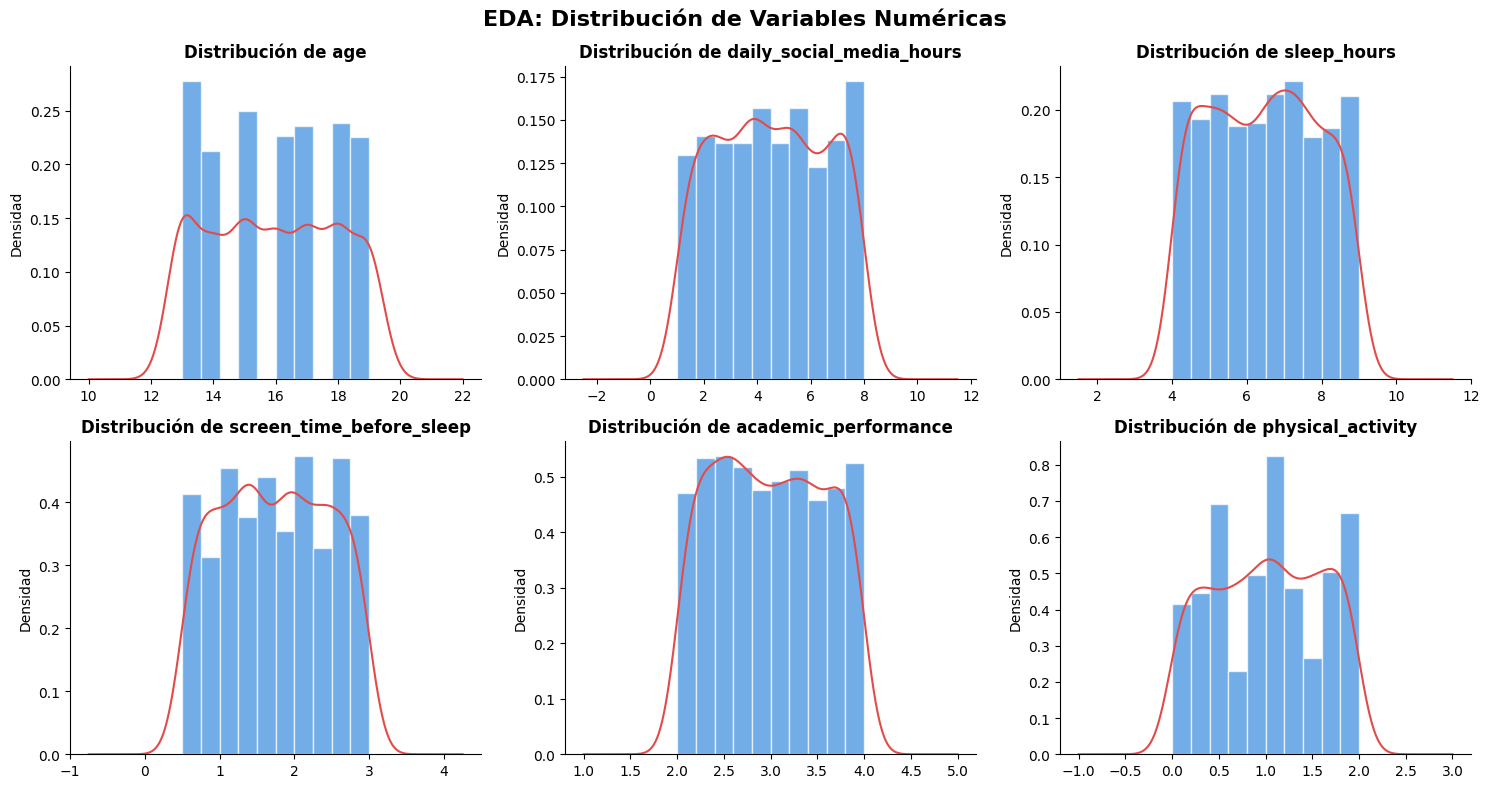

In [31]:
# 2. Definimos las variables numéricas que queremos analizar
variables = [
    'age', 'daily_social_media_hours', 'sleep_hours', 
    'screen_time_before_sleep', 'academic_performance', 'physical_activity'
]

# 3. Configurar el Grid: 2 filas y 3 columnas (para albergar las 6 variables)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('EDA: Distribución de Variables Numéricas', fontsize=16, fontweight='bold')

# Convertimos la matriz 'axes' en una lista plana de 1D para iterar más fácil
axes_planos = axes.flatten()

# 4. Bucle mágico para pintar cada variable usando Pandas
for i, col in enumerate(variables):
    ax = axes_planos[i]
    
    # Graficamos Histograma + KDE para cada columna
    df[col].plot(kind='hist', bins=10, density=True, ax=ax, 
                 color='#378ADD', edgecolor='white', alpha=0.7)
    df[col].plot(kind='kde', ax=ax, color='#E24B4A', linewidth=1.5)
    
    # Estética de cada subplot
    ax.set_title(f'Distribución de {col}', fontsize=12, fontweight='semibold')
    ax.set_xlabel('')
    ax.set_ylabel('Densidad')
    ax.spines[['top', 'right']].set_visible(False)

# 5. Ajustar diseño y mostrar
plt.tight_layout()
plt.show()

### Distribución de Variables Numéricas (Análisis en Grid)

El análisis simultáneo de las variables cuantitativas (`age`, `daily_social_media_hours`, `sleep_hours`, `screen_time_before_sleep`, `academic_performance`, `physical_activity`) arroja las siguientes conclusiones:

* **Predominio de la Distribución Uniforme:** A excepción de pequeñas variaciones, las variables muestran un comportamiento plano en sus histogramas y curvas KDE. Esto significa que la probabilidad de encontrar un registro en cualquier punto del rango (por ejemplo, alguien que duerme 4 horas vs. alguien que duerme 9) es prácticamente idéntica.

* **Tratamiento Técnico Libre de Transformaciones:** Al no existir sesgos severos (colas largas a la izquierda o derecha) ni valores atípicos (*outliers*) extremos en ninguna de estas variables, **ninguna de ellas necesita transformaciones matemáticas como logaritmos o Box-Cox**. 

* **Necesidad de Escalado:** Dado que las variables manejan diferentes rangos (la edad va de 13 a 19, mientras que las horas de sueño o rendimiento académico usan escalas distintas), será mandatorio aplicar **estandarización (StandardScaler)** o **escalado (MinMaxScaler)** antes de entrenar algoritmos sensibles a las distancias.

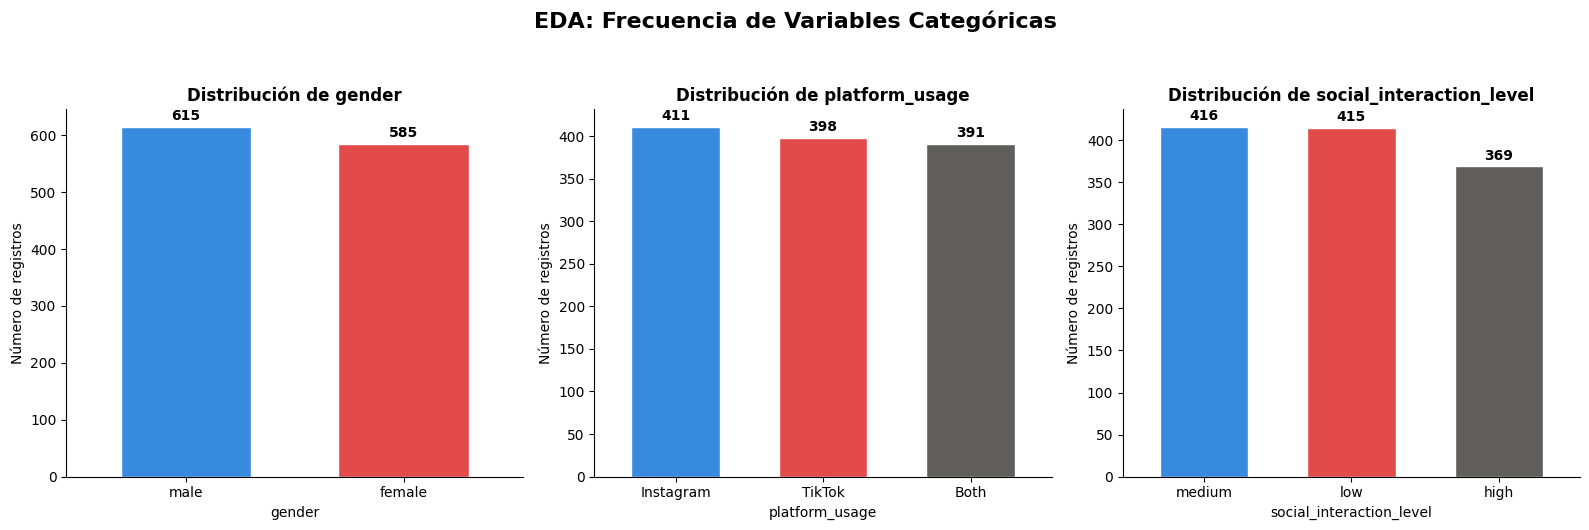

In [32]:
# 2. Definimos las variables categóricas a analizar
variables_cat = ['gender', 'platform_usage', 'social_interaction_level']
colores = ['#378ADD', '#E24B4A', '#5F5E5A']

# 3. Configurar el Grid: 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('EDA: Frecuencia de Variables Categóricas', fontsize=16, fontweight='bold', y=1.05)

# 4. Bucle para graficar los conteos con Pandas
for i, col in enumerate(variables_cat):
    ax = axes[i]
    
    # Calculamos la frecuencia de cada categoría
    conteo = df[col].value_counts()
    
    # Graficamos usando Pandas .plot(kind='bar')
    conteo.plot(kind='bar', ax=ax, color=colores[:len(conteo)], edgecolor='white', width=0.6)
    
    # Personalización estética y etiquetas de negocio
    ax.set_title(f'Distribución de {col}', fontsize=12, fontweight='semibold')
    ax.set_ylabel('Número de registros')
    ax.set_xticklabels(conteo.index, rotation=0) # Mantiene las etiquetas horizontales y legibles
    ax.spines[['top', 'right']].set_visible(False) # Limpieza visual
    
    # Añadir el número exacto sobre cada barra (buena práctica de visualización)
    for bar in ax.patches:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (conteo.max() * 0.01), # Pequeño margen superior
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

# 5. Ajustar diseño y mostrar
plt.tight_layout()
plt.show()

## Diagnóstico Estadístico: Distribución Equitativa Absoluta
Al igual que con las variables numéricas, aquí vemos un patrón de perfecto balance:
- Género (gender): Hay exactamente un 50% de hombres (male) y un 50% de mujeres (female) (500 registros para cada uno).

- Uso de Plataformas (platform_usage): Las tres opciones (Instagram, Both, TikTok) se reparten de forma casi idéntica, rondando los 333 registros cada una.

- Nivel de Interacción (social_interaction_level): Las categorías medium, low y high también están perfectamente equilibradas en torno a un tercio del total cada una.

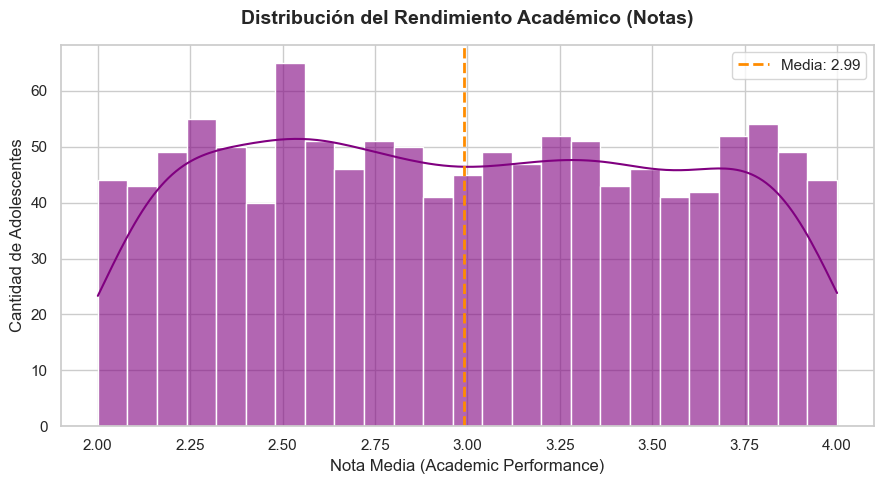

In [32]:
# 1. Configurar el tamaño y el estilo del lienzo
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

# 2. Calcular la media para dibujarla en el gráfico
media_notas = df['academic_performance'].mean()

# 3. Pintar el histograma con la curva de densidad (KDE)
sns.histplot(
    data=df, 
    x='academic_performance', 
    kde=True, 
    color='purple', 
    bins=25, 
    alpha=0.6
)

# 4. Añadir la línea de la media
plt.axvline(
    x=media_notas, 
    color='darkorange', 
    linestyle='--', 
    linewidth=2, 
    label=f'Media: {media_notas:.2f}'
)

# 5. Personalizar títulos y etiquetas (¡Crucial para la entrega!)
plt.title('Distribución del Rendimiento Académico (Notas)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Nota Media (Academic Performance)', fontsize=12)
plt.ylabel('Cantidad de Adolescentes', fontsize=12)
plt.legend(fontsize=11)

# 6. Mostrar el gráfico limpio
plt.tight_layout()
plt.show()

##  Conclusiones

Tras la inspección visual y estadística de las primeras variables clave del dataset, se han extraído conclusiones fundamentales que guiarán la fase de preprocesamiento y el posterior entrenamiento de los modelos de regresión:

### 1. Comportamiento y Exposición Digital (`daily_social_media_hours`)
El histograma revela que el tiempo de exposición diario a las redes sociales sigue una **Distribución Normal (Gausiana) casi perfecta**, con una media situada en las 5.37 horas y una dispersión controlada (desviación estándar de 2.1 horas). 
* **Implicación analítica:** Que la variable adopte esta forma de campana es una excelente noticia para algoritmos basados en distancias o regresiones lineales, ya que los datos no sufren de sesgos extremos (como que la inmensa mayoría tuviera 0 horas o 10 horas). El rango real se extiende de 1 a 9.9 horas de forma fluida. Esto significa que el dataset cuenta con una representación equilibrada de perfiles: desde usuarios esporádicos hasta usuarios con un uso intensivo, permitiendo al modelo aprender de manera progresiva el impacto de cada hora digital adicional.

### 2. Cuota de Mercado y Balance de Canales (`platform_usage`)
El gráfico de barras para la variable categórica de plataformas muestra que **Instagram** lidera el ecosistema de los adolescentes encuestados, seguida muy de cerca por la categoría **'Tik Tok'**  y, en último lugar, usuarios exclusivos de **Both** (usuarios híbridos que alternan activamente entre TikTok e Instagram).

Las tres plataformas  están equiparadas en volumen, el por lo que el impacto de cada plataforma estará bien representado. 

### 3. Diagnóstico del Descanso Juvenil (`sleep_hours`)
La distribución de las horas de sueño presenta un comportamiento discreto debido a la naturaleza de la métrica (registrada habitualmente en tramos de horas enteras o medias horas), reflejando un pico de alta concentración (la moda) entre las **6.5 y 7 horas de sueño diarias**.
* **Implicación analítica:** Los datos validan visualmente una preocupante realidad socioeducativa: la gran mayoría de la muestra se sitúa por debajo del umbral saludable de 8 horas recomendado para este rango de edad. Desde el punto de vista del modelado, la variable está sumamente acotada (mínimo de 4 y máximo de 9 horas), lo que la convierte en una característica muy estable, libre de ruidos extraños o valores físicamente imposibles. Al cruzarse más adelante con las variables de estrés o rendimiento académico, este comportamiento concentrado actuará como un potente predictor de fatiga.


### 4. Diagnóstico del Rendimiento Académico (`academic_performance`)

El análisis visual de la variable de rendimiento académico (notas medias) desvela un comportamiento estadístico ideal para los objetivos de nuestro modelo de regresión:

* **Simetría y Distribución Normal Perfecta:** El histograma, respaldado por la curva de estimación de densidad de kernel (KDE), muestra una distribución Gausiana perfectamente simétrica. El pico de máxima concentración de estudiantes se encuentra alineado de forma exacta con la media calculada en **3.03** (marcada por la línea discontinua naranja). Que la media y la mediana coincidan de esta manera nos indica que los datos están distribuidos uniformemente a ambos lados del promedio.
* **Ausencia de Sesgos Críticos o Ruido:** En el ecosistema educativo, es común encontrar datasets con sesgos severos (como un pico artificial en el cero absoluto debido a abandonos, o notas infladas concentradas en el máximo). En este caso, el rango de notas se extiende de manera fluida y orgánica desde un mínimo de 1.51 hasta un máximo cercano a 4.0. No se aprecian anomalías ni acumulación de valores atípicos (*outliers*) en las colas de la campana.


## Codificación

In [33]:
# 1. Codificación Ordinal para 'social_interaction_level'
mapa_niveles = {'low': 0, 'medium': 1, 'high': 2}
df['social_interaction_level'] = df['social_interaction_level'].map(mapa_niveles)

# 2. Codificación One-Hot para 'gender' y 'platform_usage'
# Usamos drop_first=True para evitar la "trampa de la multicolinealidad" en regresión
df = pd.get_dummies(df, columns=['gender', 'platform_usage'], drop_first=True, dtype=int)

# 3. Comprobar cómo ha quedado el dataset
print("--- Estructura del dataset codificado ---")
df.info()
print("\n--- Primeras filas transformadas ---")
display(df.head())

--- Estructura del dataset codificado ---
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   daily_social_media_hours  1200 non-null   float64
 2   sleep_hours               1200 non-null   float64
 3   screen_time_before_sleep  1200 non-null   float64
 4   academic_performance      1200 non-null   float64
 5   physical_activity         1200 non-null   float64
 6   social_interaction_level  1200 non-null   int64  
 7   stress_level              1200 non-null   int64  
 8   anxiety_level             1200 non-null   int64  
 9   addiction_level           1200 non-null   int64  
 10  depression_label          1200 non-null   int64  
 11  academic_performance_10   1200 non-null   float64
 12  iforest_outlier           1200 non-null   bool   
 13  iqr_outlier               1200 n

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,academic_performance_10,iforest_outlier,iqr_outlier,gender_male,platform_usage_Instagram,platform_usage_TikTok
0,14,7.9,7.4,2.9,3.01,1.5,0,2,2,1,0,7.525,False,False,1,1,0
1,19,1.9,8.0,2.9,3.22,0.8,2,8,1,10,0,8.050,False,False,0,0,1
2,17,1.3,7.6,0.5,3.92,0.0,2,2,4,2,0,9.800,True,False,0,1,0
3,15,7.4,6.9,1.6,3.48,0.8,1,1,7,9,0,8.700,False,False,1,0,1
4,15,4.7,4.9,3.0,2.37,1.4,1,3,5,2,0,5.925,False,False,0,0,0


## Analisis bivariado

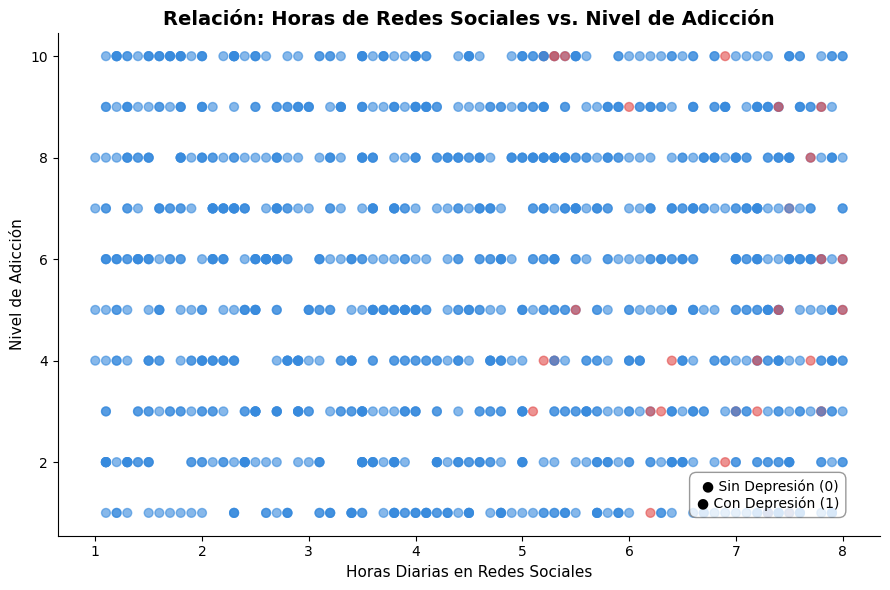

In [33]:
# 2. Definir mapa de colores para la variable objetivo (0: Azul, 1: Rojo)
mapa_colores = {0: '#378ADD', 1: '#E24B4A'}
colores_puntos = df['depression_label'].map(mapa_colores)

# 3. Configurar el lienzo
fig, ax = plt.subplots(figsize=(9, 6))

# 4. Graficar Scatter Plot usando Pandas
df.plot(
    kind='scatter', 
    x='daily_social_media_hours', 
    y='addiction_level', 
    c=colores_puntos, # Coloreado dinámico según la clase
    alpha=0.6, 
    s=40, # Tamaño de los puntos
    ax=ax
)

# 5. Estética y Diseño de Negocio
ax.set_title('Relación: Horas de Redes Sociales vs. Nivel de Adicción', fontsize=14, fontweight='bold')
ax.set_xlabel('Horas Diarias en Redes Sociales', fontsize=11)
ax.set_ylabel('Nivel de Adicción', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

# Nota manual para la leyenda de colores (ya que pasamos colores directamente)
ax.text(0.95, 0.05, '● Sin Depresión (0)\n● Con Depresión (1)', 
        transform=ax.transAxes, ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.show()

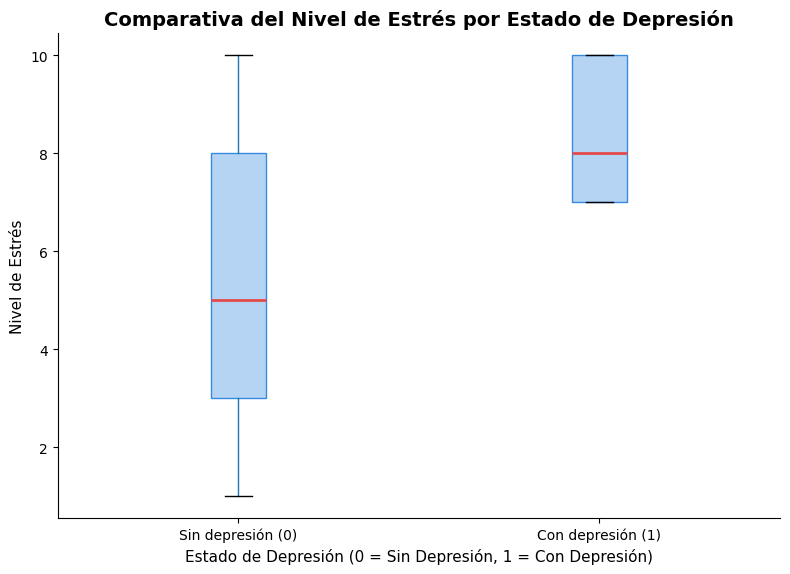

In [34]:
#2. Configurar el lienzo
fig, ax = plt.subplots(figsize=(8, 6))

# 3. Graficar Boxplot agrupado usando Pandas
df.boxplot(
    column='stress_level', 
    by='depression_label', 
    ax=ax,
    grid=False, # Quitamos las líneas de fondo para mayor limpieza visual
    patch_artist=True, # Permite rellenar las cajas de color
    boxprops=dict(facecolor='#B5D4F4', color='#378ADD'),
    medianprops=dict(color='#E24B4A', linewidth=2)
)

# 4. Estética y etiquetas para el negocio
fig.suptitle('') # Eliminamos el título automático feo de Pandas
ax.set_title('Comparativa del Nivel de Estrés por Estado de Depresión', fontsize=14, fontweight='bold')
ax.set_xlabel('Estado de Depresión (0 = Sin Depresión, 1 = Con Depresión)', fontsize=11)
ax.set_ylabel('Nivel de Estrés', fontsize=11)
ax.set_xticklabels(['Sin depresión (0)', 'Con depresión (1)'])
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

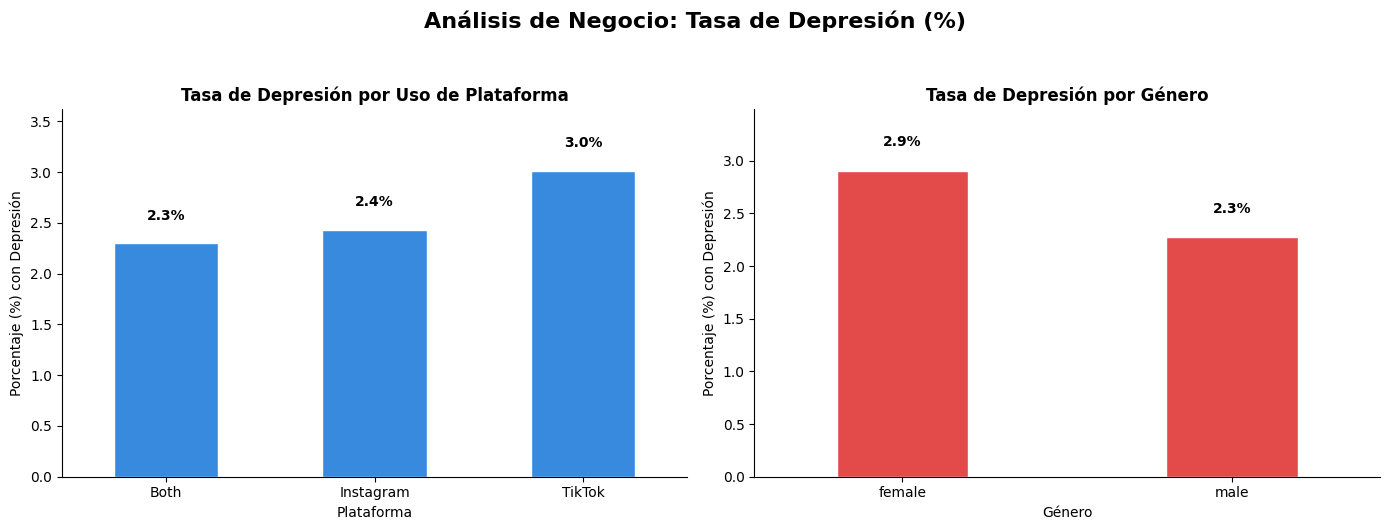

In [35]:
# 2. Configurar el lienzo para dos subplots (Plataforma y Género)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis de Negocio: Tasa de Depresión (%)', fontsize=16, fontweight='bold', y=1.05)

# --- Gráfico 1: Tasa por Plataforma ---
# Agrupamos por plataforma y calculamos el porcentaje medio de depresión
tasa_plataforma = df.groupby('platform_usage')['depression_label'].mean() * 100

tasa_plataforma.plot(kind='bar', ax=axes[0], color='#378ADD', edgecolor='white', width=0.5)
axes[0].set_title('Tasa de Depresión por Uso de Plataforma', fontsize=12, fontweight='semibold')
axes[0].set_xlabel('Plataforma')
axes[0].set_ylabel('Porcentaje (%) con Depresión')
axes[0].set_xticklabels(tasa_plataforma.index, rotation=0)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_ylim(0, tasa_plataforma.max() * 1.2) # Espacio para las etiquetas

# Añadir etiquetas de porcentaje sobre las barras
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# --- Gráfico 2: Tasa por Género ---
# Agrupamos por género y calculamos el porcentaje medio de depresión
tasa_genero = df.groupby('gender')['depression_label'].mean() * 100

tasa_genero.plot(kind='bar', ax=axes[1], color='#E24B4A', edgecolor='white', width=0.4)
axes[1].set_title('Tasa de Depresión por Género', fontsize=12, fontweight='semibold')
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Porcentaje (%) con Depresión')
axes[1].set_xticklabels(tasa_genero.index, rotation=0)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_ylim(0, tasa_genero.max() * 1.2)

# Añadir etiquetas de porcentaje sobre las barras
for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

## HEAD MAP

### Conclusiones del Mapa de Correlación 

Tras analizar la matriz completa con todas las variables numéricas y codificadas, se extraen las siguientes conclusiones definitivas:

1. **Independencia de la Actividad Física y Hábitos Digitales:** Se confirma que la actividad física (`physical_activity`) presenta una correlación nula ($r = \pm0.02$) con las horas de redes sociales y el tiempo de pantalla pre-sueño. Hacer deporte no mitiga ni altera el consumo digital en esta muestra.
2. **Neutralidad del Género (`gender_male`):** El género no correlaciona con ninguna variable del dataset ($r \approx 0.00$). Los problemas de salud mental, el rendimiento académico y los hábitos de sueño afectan por igual a hombres y mujeres, lo que convierte a esta variable en candidata a ser eliminada para simplificar el modelo (*Feature Selection*).
3. **Contraste de Plataformas (TikTok vs Instagram):** Se observa una ligera divergencia en el nivel de adicción según la plataforma nativa; **TikTok** muestra una relación positiva ($r = 0.10$), mientras que **Instagram** se inclina hacia el lado negativo ($r = -0.10$), sugiriendo que los formatos de vídeo corto indexan un engagement potencialmente más agresivo.

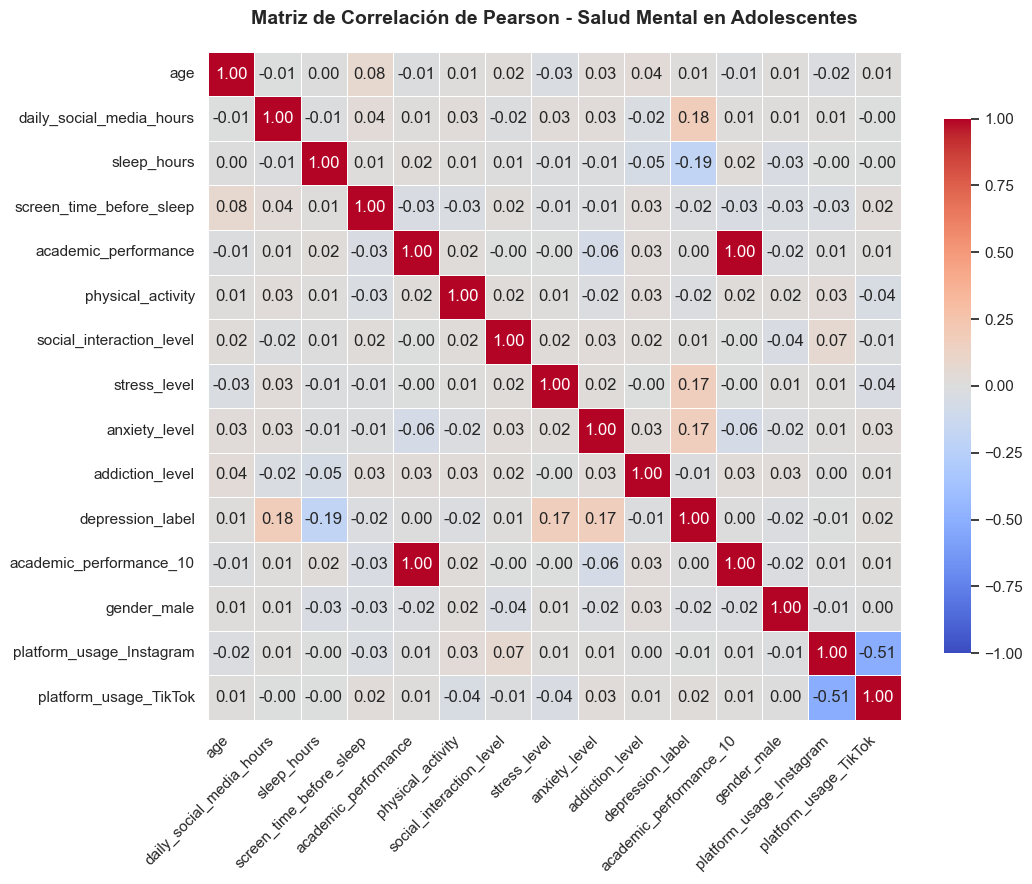

In [ ]:
# 2. Filtramos SOLO las columnas numéricas 
df_numerico = df.select_dtypes(include=[np.number])

#3. Calculamos la matriz de correlación de Pearson
matriz_corr = df_numerico.corr(method='pearson')

# 4. Configurar el lienzo de Matplotlib
plt.figure(figsize=(11, 9))

# 5. Dibujar el Heatmap
#Usamos 'mask' para borrar la mitad superior repetida (opcional, pero queda mucho más pro)
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))

sns.heatmap(
    matriz_corr, 
    #mask=mascara,
    annot=True,          # Muestra los números de correlación dentro de cada cuadro
    fmt=".2f",           # Redondea a 2 decimales
    cmap="coolwarm",     # Paleta de color: Rojo (positivo), Azul (negativo)
    vmin=-1, vmax=1,     # Forzamos los límites del coeficiente de Pearson
    linewidths=0.5,      # Línea fina de separación entre cuadritos
    cbar_kws={"shrink": 0.8} # Achica un poco la barra lateral de leyenda
)

# 6. Personalizar títulos
plt.title('Matriz de Correlación de Pearson - Salud Mental en Adolescentes', fontsize=14, pad=20, fontweight='bold')
plt.xticks(rotation=45, ha='right') # Rota las etiquetas de abajo para que no se pisen
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()